# DistilBERT Fine-Tuning using TensorFlow/Keras

## Objectives

- Fine-tune a pretrained DistilBERT model for multi-label toxic comment classification.
- Leverage transfer learning by using pretrained language representations from Hugging Face.
- Build a custom classification head using TensorFlow/Keras.
- Train and evaluate the model using Binary Crossentropy and standard classification metrics.
- Compare the transformer-based approach with classical machine learning models.
- Save the trained model for future inference and deployment.

In [1]:
!pip uninstall -y transformers
!pip install -q transformers==4.44.2 tf-keras

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 78.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 83.7 MB/s eta 0:00:00:00:01


In [2]:
%pip install -q tf-keras

Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split

from transformers import (
    DistilBertTokenizerFast,
    TFDistilBertModel
)

In [4]:
train = pd.read_csv(
    "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv"
)

labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

In [5]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
def preprocess_text(text):

    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [7]:
train["clean_comment"] = train["comment_text"].apply(preprocess_text)

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(train["clean_comment"], train[labels],
                                     test_size=0.2, random_state=42)

print(X_train.shape)
print(X_valid.shape)

(127656,)
(31915,)


In [9]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
# Tokenize training comments

train_tokens = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="tf",
)

I0000 00:00:1788309138.767061      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788309138.769957      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
# Tokenize validation comments

valid_tokens = tokenizer(
    X_valid.tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="tf",
)

In [12]:
print(train_tokens.keys())

dict_keys(['input_ids', 'attention_mask'])


- input_ids: The numbers representing the words.
- attention_mask: Tells the model which values are actual words (1) and which are padding (0).

In [13]:
print(train_tokens["input_ids"].shape)
print(train_tokens["attention_mask"].shape)
print(y_train.shape)

(127656, 256)
(127656, 256)
(127656, 6)


In [14]:
bert = TFDistilBertModel.from_pretrained(
    "distilbert-base-uncased"
)

bert.trainable = True

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [15]:
print(type(bert))

<class 'transformers.models.distilbert.modeling_tf_distilbert.TFDistilBertModel'>


In [16]:
import tf_keras

from tf_keras.layers import (
    Input,
    Dense,
    Dropout
)

from tf_keras.models import Model
from tf_keras.optimizers import Adam

In [17]:
input_ids = Input(
    shape=(256,),
    dtype=tf.int32,
    name="input_ids"
)

attention_mask = Input(
    shape=(256,),
    dtype=tf.int32,
    name="attention_mask"
)

In [18]:
bert_outputs = bert(
    input_ids=input_ids,
    attention_mask=attention_mask
)

In [19]:
cls_embedding = bert_outputs.last_hidden_state[:, 0, :]

In [20]:
x = Dropout(0.3)(cls_embedding)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.2)(x)

outputs = Dense(
    6,
    activation="sigmoid",
    name="classifier"
)(x)

In [21]:
model = Model(
    inputs=[
        input_ids,
        attention_mask,
    ],

    outputs=outputs,

    name="DistilBERT_Toxic_Comment_Classifier"
)

In [22]:
model.compile(optimizer=Adam(learning_rate=2e-5),

    loss="binary_crossentropy",

    metrics=[
        tf_keras.metrics.BinaryAccuracy(name="accuracy"),
        tf_keras.metrics.Precision(name="precision"),
        tf_keras.metrics.Recall(name="recall"),
    ]
)

In [23]:
model.summary()

Model: "DistilBERT_Toxic_Comment_Classifier"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, 256, 768)   0          'attention_mask[0][0]']      
                             , hidden_states=None, atte         

In [24]:
EPOCHS = 2

history = model.fit(
    x={
        "input_ids": train_tokens["input_ids"],
        "attention_mask": train_tokens["attention_mask"],
    },
    y=y_train,

    validation_data=(
        {
            "input_ids": valid_tokens["input_ids"],
            "attention_mask": valid_tokens["attention_mask"],
        },
        y_valid,

    ),

    epochs=EPOCHS,
    batch_size=64
)

Epoch 1/2


I0000 00:00:1788309222.770632     152 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1995/1995 [==============================] - 3815s 2s/step - loss: 0.0511 - accuracy: 0.9812 - precision: 0.7778 - recall: 0.6817 - val_loss: 0.0400 - val_accuracy: 0.9839 - val_precision: 0.8915 - val_recall: 0.6409
Epoch 2/2
1995/1995 [==============================] - 3792s 2s/step - loss: 0.0362 - accuracy: 0.9855 - precision: 0.8258 - recall: 0.7645 - val_loss: 0.0366 - val_accuracy: 0.9850 - val_precision: 0.8258 - val_recall: 0.7539


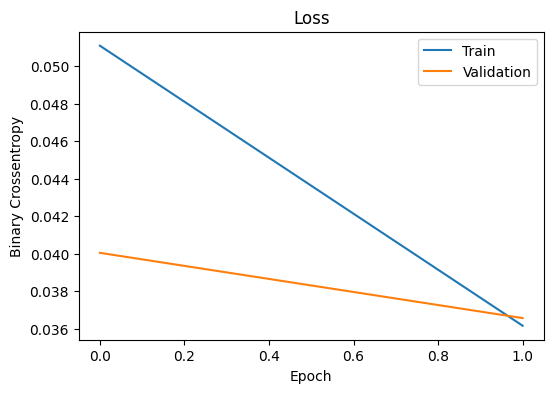

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.show()

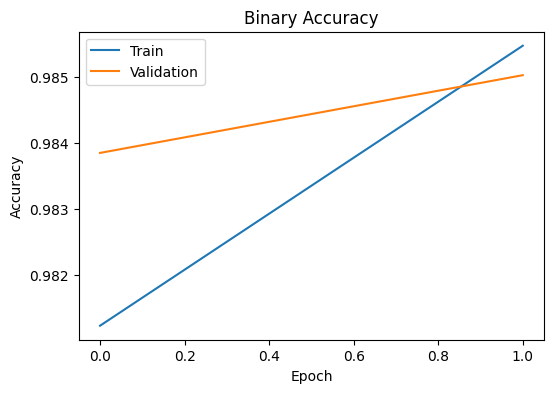

In [26]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Binary Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
predictions = model.predict(
    {
        "input_ids": valid_tokens["input_ids"],
        "attention_mask": valid_tokens["attention_mask"],
    }
)

predictions = (predictions >= 0.5).astype(int)

998/998 [==============================] - 319s 318ms/step


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

accuracy = accuracy_score(y_valid, predictions)
precision = precision_score(y_valid, predictions, average="micro")
recall = recall_score(y_valid, predictions, average="micro")
f1 = f1_score(y_valid, predictions, average="micro")

results = pd.DataFrame({

    "Model": ["DistilBERT"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,DistilBERT,0.929281,0.825797,0.753887,0.788206
